<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana1/CargadeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
a = 7
a

7

In [22]:
# Como cargar el drive en python, comment
# Sintaxis -> una forma de escribir

from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [23]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_MachineLearning/Semana1/')

In [24]:
# Donde estoy, la admiracion significa que es linux
!pwd

/content/drive/MyDrive/EDCO_MachineLearning/Semana1


In [25]:
# Que hay???
!ls  # Esto es busqueda recursiva

CargadeDatos.ipynb  Data  QuejasAmbientales.ipynb


In [26]:
# Cargamos nuestros datos
import pandas as pd

In [27]:
Data = pd.read_csv('Data/MediaMovilData.csv', sep=',')

In [28]:
#type(Data)

In [29]:
Data.shape
# Las filas: el numero de datos que tenemos
# Las columnas: el numero de caracteristicas

(18, 1)

In [30]:
# Necesitamos la informacion
x = Data['Ventas'].values
# esto es una lista
x

array([1250, 1150,  970, 1100, 1170, 1080, 1120, 1230, 1210, 1050, 1030,
        990, 1160, 1200, 1180, 1260, 1230, 1190])

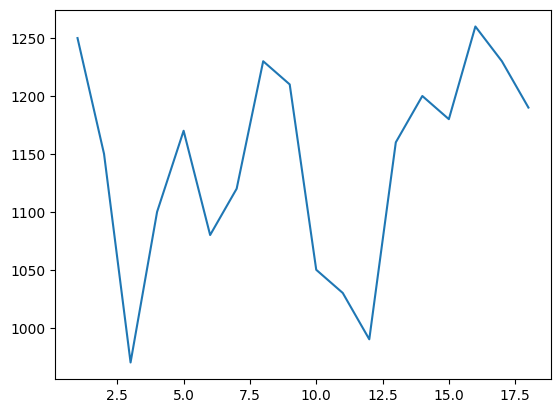

In [31]:
# La graficación es muy importante!!!!
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(1,len(x)+1,1),x)
plt.show()

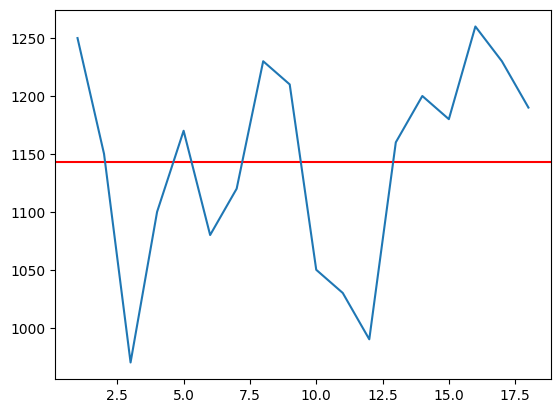

In [32]:
# QUiere saber cuánto va a vender al siguiente dia? día 19
# calcular le promedio
media = np.mean( x )
plt.axhline(y=media, color='r', linestyle='-')
plt.plot(np.arange(1,len(x)+1,1),x)
plt.show()

In [33]:
# Este es un modelo demasiado SIMPLE para describir lo que pasa: Este es un caso de underfitting!
# Entonces si el modelo es muy simple -> complejizar el modelo

In [34]:
# Definir una funcion
def GetMediaMovil(x,n):
  # Los datos y el numero de dias

  # GUardamos
  media = np.zeros( len(x) + 1 )

  for i in range( len(media) ):

    sum_ = 0.

    if i >= n:

      for j in range( i-n, i ):

        sum_ += x[j]

      media[i] = sum_/n # Promedio aritmetico

    else:
      media[i] = x[i]

  return media

In [35]:
media_ = GetMediaMovil(x,3) # Usamos 3 dias
media_[-1] # Deme el ultimo

np.float64(1226.6666666666667)

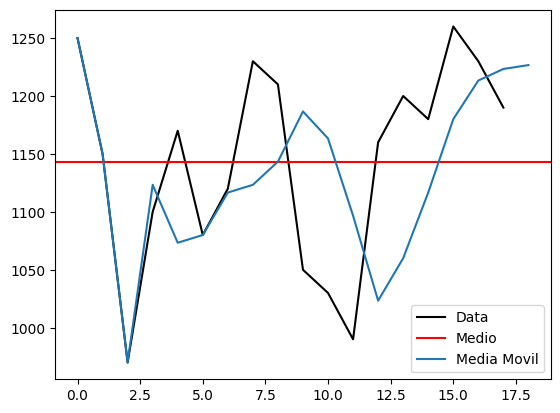

In [36]:
media = np.mean( x )
plt.plot(x, color='k',label='Data')
plt.axhline(y=media, color='r', linestyle='-', label='Medio')
plt.plot(media_, label='Media Movil')
plt.legend()
plt.show()

In [37]:
# Definir una funcion para hacer una media movil ponderada

def GetWeightedMediaMovil(x,w):
  # Los datos y del vector de pesos
  # Hacer un modelo parametrico

  n = len(w)

  # GUardamos
  media = np.zeros( len(x) + 1 )

  for i in range( len(media) ):

    sum_ = 0.

    if i >= n:

      k = 0

      for j in range( i-n, i ):

        sum_ += w[k]*x[j]
        k += 1

      media[i] = sum_ # Promedio pesado

    else:
      media[i] = x[i]

  return media

In [38]:
# Definamos un posible modelo
w = np.array([1/3.,1/3.,1/3])
Wmedia_ = GetWeightedMediaMovil(x,w)
Wmedia_[-1] # Deme el ultimo

np.float64(1226.6666666666665)

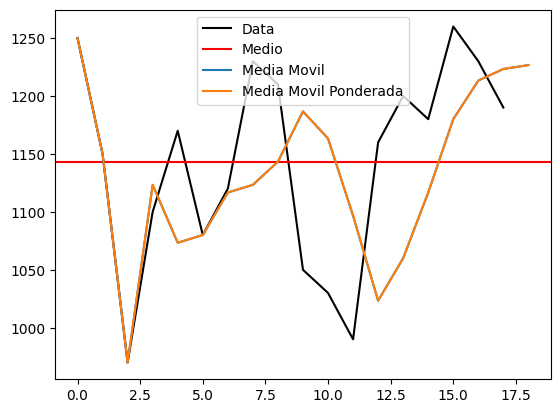

In [39]:
media = np.mean( x )
plt.plot(x, color='k',label='Data')
plt.axhline(y=media, color='r', linestyle='-', label='Medio')
plt.plot(media_, label='Media Movil')
plt.plot(Wmedia_, label='Media Movil Ponderada')
plt.legend()
plt.show()

In [40]:
# Como encontramos el mejor modelo posible?
# Queremos que el modelo de media movil se equivoque "en promedio" lo menos posible

In [41]:
def GetError(x,y):
  # X es el muestreo (Datos)
  # Y es el valor que predice el modelo
  return np.mean( np.abs(x-y) )

In [42]:
GetError(x,Wmedia_[-1])

np.float64(90.92592592592584)

In [43]:
# Como encontramos el mejor posible?
def Cost(w):

  Wmedia = GetWeightedMediaMovil(x,w)

  return GetError(x,Wmedia[:-1])

In [44]:
Cost([0.1,0.2,0.7])

np.float64(57.166666666666664)

In [45]:
import scipy.optimize as optimize
from scipy.stats import norm

In [55]:
# Como funciona el paquete
constraints = ({'type':'eq', 'fun': lambda w: 1-sum(w)}) # Funcion anonima
bounds = ((0,1),(0,1),(0,1))
# UNa semilla
w0 = np.array([0.1,0.4,0.5])
# Queremos minimizar la metrica
result = optimize.minimize( Cost, w0, method='Nelder-Mead', constraints=constraints, bounds = bounds )
result

/tmp/ipykernel_1355/745886951.py:7: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  result = optimize.minimize( Cost, w0, method='Nelder-Mead', constraints=constraints, bounds = bounds )


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 51.259685103464385
             x: [ 2.702e-01  5.013e-06  7.604e-01]
           nit: 160
          nfev: 292
 final_simplex: (array([[ 2.702e-01,  5.013e-06,  7.604e-01],
                       [ 2.702e-01,  3.938e-06,  7.604e-01],
                       [ 2.702e-01,  6.436e-06,  7.604e-01],
                       [ 2.702e-01,  1.378e-05,  7.604e-01]]), array([ 5.126e+01,  5.126e+01,  5.126e+01,  5.126e+01]))

In [62]:
wopt = result.x
np.round(wopt,5)

array([2.7016e-01, 1.0000e-05, 7.6044e-01])

In [63]:
OptMean = GetWeightedMediaMovil(x,wopt)
OptMean[-1]

np.float64(1245.3404838079568)

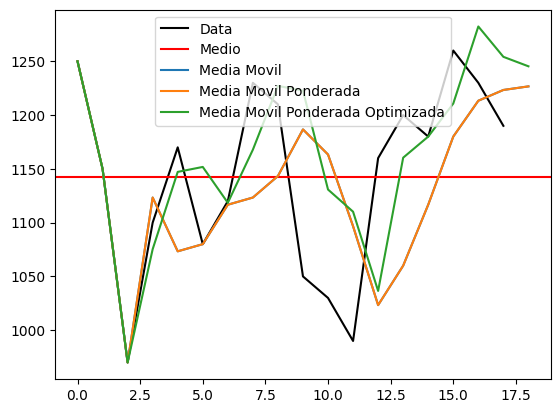

In [64]:
media = np.mean( x )
plt.plot(x, color='k',label='Data')
plt.axhline(y=media, color='r', linestyle='-', label='Medio')
plt.plot(media_, label='Media Movil')
plt.plot(Wmedia_, label='Media Movil Ponderada')
plt.plot(OptMean, label='Media Movil Ponderada Optimizada')
plt.legend()
plt.show()

In [60]:
std

np.float64(51.259685103464385)